# SIT744 Assignment 3 (T2 2025)

FULL NAME: DUONG SON THONG (Dalex)


STUDENT ID: 223593948


## Task 1.1 Define the Problem

The problem we are addressing is **sentiment recognition from images**. Specifically, we want to automatically classify human emotions expressed visually into predefined categories using deep learning. This is an **image classification task** where the system learns to detect subtle and explicit cues in facial expressions, gestures, and other features to determine the underlying emotion.

---

### What are we trying to solve?
We aim to develop a Convolutional Neural Network (CNN) that can accurately recognize and classify emotions in images.  
The goal is to enable machines to interpret human emotions, which is useful in areas such as:
- Mental health monitoring  
- Human–computer interaction  
- Customer service  
- Safety and surveillance applications  

---

### Inputs and outputs of the system
- **Input:** An image containing a human face or expression  
- **Output:** A predicted emotion label from one of the six categories  

---

### Target classes
1. **Happy** – smiles, raised cheeks, brightened eyes  
2. **Sad** – downturned mouth, drooping eyelids, tears in some cases  
3. **Fear** – wide-open eyes, tense mouth, defensive body posture  
4. **Pain** – tightened face muscles, clenched teeth, grimacing  
5. **Anger** – frowning eyebrows, glaring eyes, pursed lips  
6. **Disgust** – wrinkled nose, curled lip, squinting eyes  

---

### Why misclassification is problematic?
Misclassifying emotions can have serious consequences:
- Confusing **Fear with Pain** may hinder proper emergency or psychological support  
- Mislabeling **Anger as Disgust** could lead to incorrect responses in conflict detection systems  
- Errors in detecting **Sadness as Happiness** could cause an empathetic technology to fail in providing necessary comfort or intervention  

In real-world contexts like healthcare, law enforcement, or education, such errors can reduce trust in the system and potentially cause harm.

## Task 1.2 Analysis and Planning



### Import Module

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from pathlib import Path
import cv2
from PIL import Image
plt.style.use('default')
sns.set_palette("husl")

### A. Train/Validation/Test Split Ratio

**Split for our dataset (1,200 images): 70% Train / 15% Validation / 15% Test**
- **Training set:** ~803 images (~134 per class on average)
- **Validation set:** ~172 images (~29 per class on average)  
- **Test set:** ~173 images (~29 per class on average)

**Justification:**
- **Medium-sized dataset consideration:** With 1,200 total images, we have a medium-sized dataset that requires careful splitting
- **Minimum samples per class:** Each class will have at least 23 samples in validation/test sets (based on smallest class having 163 images)
- **Stratified splitting essential:** Must maintain the existing class distribution (Happy: 20%, Anger: 18.6%, Sad: 19.5%, etc.) across all splits
- **Alternative for imbalanced classes:** Upsample minor class

**Class-specific considerations:**
- **Fear & Disgust (163 images each):** Will have ~111 training, ~24 validation, ~24 test samples
- **Happy (230 images):** Will have ~161 training, ~35 validation, ~34 test samples
- This ensures adequate representation of all emotions in each split

### B. Dataset Balance Analysis - Actual Results

**Quantitative analysis**



Using Colab cache for faster access to the 'sentiment-images-classifier' dataset.
Path to dataset files: /kaggle/input/sentiment-images-classifier


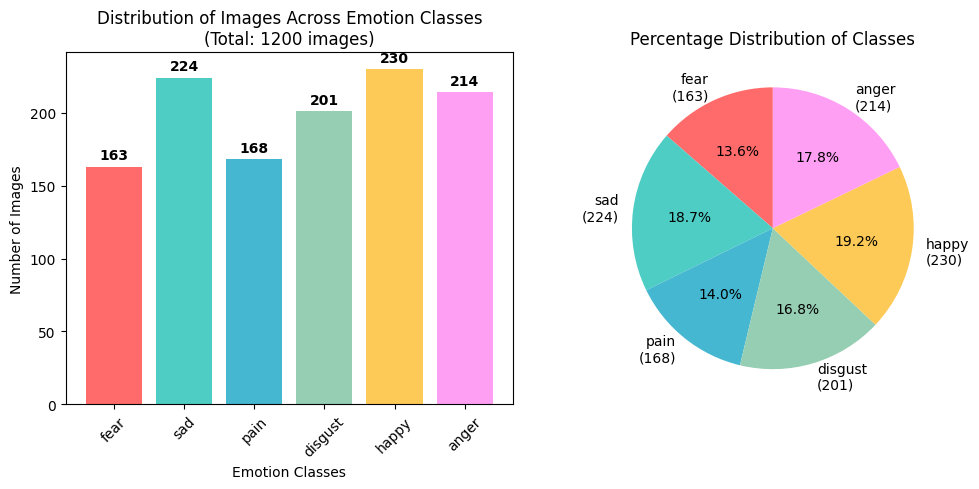

In [2]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("yousefmohamed20/sentiment-images-classifier")
print("Path to dataset files:", path)

FOLDER_NAME = '6 Emotions for image classification'
emotions_path = os.path.join(path, FOLDER_NAME)  # Use the actual folder name
class_counts = {}

if os.path.exists(emotions_path):
    for item in os.listdir(emotions_path):
        item_path = os.path.join(emotions_path, item)
        if os.path.isdir(item_path):
            count = len([f for f in os.listdir(item_path) ])  # Filter image files
            class_counts[item] = count
else:
    print(f"Emotions folder not found at: {emotions_path}")
    # Alternative: check if emotions folder is directly in kagglehub path
    if os.path.exists(path):
        print("Available folders in kagglehub path:")
        print(os.listdir(path))

emotion_classes = list(class_counts.keys())
counts = list(class_counts.values())
total_images = sum(counts)

# Create figure with subplots
plt.figure(figsize=(15, 5))

# 1. Bar plot showing absolute counts
plt.subplot(1, 3, 1)
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FECA57', '#FF9FF3']
bars = plt.bar(emotion_classes, counts, color=colors)
plt.title(f'Distribution of Images Across Emotion Classes\n(Total: {total_images} images)', fontsize=12)
plt.xlabel('Emotion Classes')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)

# Add value labels on bars
for bar, count in zip(bars, counts):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 3,
             f'{count}', ha='center', va='bottom', fontweight='bold')

# 2. Pie chart showing percentages
plt.subplot(1, 3, 2)
percentages = [(count/total_images)*100 for count in counts]
plt.pie(percentages, labels=[f'{emotion}\n({count})' for emotion, count in zip(emotion_classes, counts)],
        autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Percentage Distribution of Classes', fontsize=12)

plt.tight_layout()
plt.show()

**Class Distribution (Total: 1,200 images):**
- **Happy:** 230 images (19.2%) - **Overrepresented**
- **Sad:** 224 images (18.7%) - **Overrepresented**
- **Anger:** 214 images (17.8%) - **Balanced**
- **Pain:** 168 images (14.0%) - **Underrepresented**
- **Fear:** 163 images (13.6%) - **Underrepresented**
- **Disgust:** 201 images (16.8%) - **Balanced**

**Impact on Learning Dynamics:**
- **Underrepresented classes (Fear, Pain):**
  - Risk of poor recall/sensitivity
  - May learn fewer discriminative features
  - Higher chance of misclassification as majority classes
- **Balanced classes (Anger, Disgust):**
  - Contribute near their expected share to gradient updates
  - Help stabilize decision boundaries for these categories
- **Overrepresented classes (Happy, Sad):**
  - Will dominate gradient updates
  - Risk of model bias toward these emotions
  - May achieve high recall but lower precision

### C. Class Imbalance and Gradient Bias

Why Gradient Updates Get Biased
- In practical terms, if a batch contains 95% majority class and 5% minority class, then the majority class contributes most of the loss that drives parameter updates.
- This imbalance causes the neural network to allocate representational resources and learning capacity preferentially toward the majority class.
- Over time, this results in poor recall and precision for the minority class, as their rare examples have little influence on gradient direction
The corrective techniques could be applied is data augmentation

Corrective techiniques could be applied to balance data

- Reweighting loss functions: apply class weights (inverse frequency, median frequency, or effective-number) in cross-entropy so minority-class errors contribute more to gradients.
- Oversampling (class-balanced sampling): sample minority classes more often (or duplicate them) so each batch has a more uniform class mix, reduces bias in gradient estimates.
- Data augmentation (label-preserving): generate diverse variants of minority images (flip, small rotation, crop/resize, color jitter, noise). Increases minority diversity and reduces overfitting. Apply to training only.
- Class-balanced batches/Weighted sampler: enforce equal per-class counts per batch for stable training dynamics.

### D. Design a preprocessing workflow for the images, covering resizing, normalization, augmentation, and feature scaling

1) Resizing
- Resizing converts each input image to a fixed dimension, creating a uniform shape across the dataset. This is vital because deep learning models require consistent input sizes for efficient tensor computation and hardware acceleration
- Effect on model:
    -   Too small: May lose facial micro-expressions crucial for distinguishing (Fear vs. Pain)
    -   Too large: Slower training without proportional accuracy gains

2) Normalization
- Effect on Data: Transforms pixel values from [0,255] integer range to [0,1] float range
- Effect on convergence: Reduces activation skew and helps gradient-based optimization converge faster and more reliably, avoiding exploding/vanishing gradients

3) Augmentation
- Effect on Data
  - Artificially expands the training dataset by creating diverse variants of existing images
  - Helps balance minority classes by generating more examples during training
- Effect on Model Convergence
  - Acts as regularization: prevents overfitting by forcing the model to learn robust features rather than memorizing specific image details
  - Improves generalization: model learns to recognize emotions across various lighting, pose, and presentation conditions


4) Feature scaling
- ensure inputs to the network (pixels or extracted features) have a bounded, comparable range (via the normalization above). Inside the model, BatchNorm/LayerNorm further normalizes intermediate features.
- Effect on Data
  - Standardizes input features to similar scales (e.g., all pixel values in [0,1] or standardized with mean=0, std=1)
  - Prevents any single feature dimension from dominating due to scale differences
  - Creates uniform feature distributions across channels/dimensions
  - Ensures all input features contribute equally to initial computations

- Effect on Model Convergence
  - Stabilizes gradients: prevents exploding/vanishing gradients by maintaining reasonable activation magnitudes
  - Speeds up training: allows use of higher learning rates without numerical instability
  - Better generalization: helps optimizer find flatter minima that generalize better to new data

### E. Training Sample Size vs. Model Performance

**Small Dataset Effects:**
- **Underfitting risk:** Insufficient data to learn complex patterns → high bias, poor training accuracy
- **Overfitting tendency:** Model memorizes limited examples → large train/validation gap
- **Poor generalization:** Limited diversity in training data → fails on unseen variations

**Large Dataset Effects:**
- **Better pattern learning:** More examples → robust feature extraction, lower bias
- **Reduced overfitting:** Harder to memorize diverse examples → better train/validation alignment
- **Improved generalization:** Exposure to more variations → better performance on test data

**Interaction with Model Complexity:**

| Dataset Size | Simple Model | Complex Model |
|--------------|--------------|---------------|
| **Small** | May underfit but stable | High overfitting risk |
| **Large** | May underfit complex patterns | Optimal performance zone |

**Key Relationships:**
- **Small data + Complex model:** Severe overfitting (memorization dominant)
- **Small data + Simple model:** Underfitting but more stable
- **Large data + Complex model:** Best performance (sufficient data to constrain complexity)
- **Large data + Simple model:** Underfitting (model too constrained)

**For Our Emotion Dataset:**
- Medium-sized dataset requires careful complexity tuning
- Use regularization (dropout, BatchNorm) to prevent overfitting
- Consider transfer learning to leverage pre-trained features
- Data augmentation effectively increases dataset size for better generalization


## Task 1.3 Implement a solution

### A. Load the dataset and perform the  preprocessing steps

Total images: 1198
Classes: ['anger', 'disgust', 'fear', 'happy', 'pain', 'sad']
data set path = /kaggle/input/sentiment-images-classifier/6 Emotions for image classification
Train: 181, Val: 838, Test: 179
132028454627728 132028454311200 132028477630816


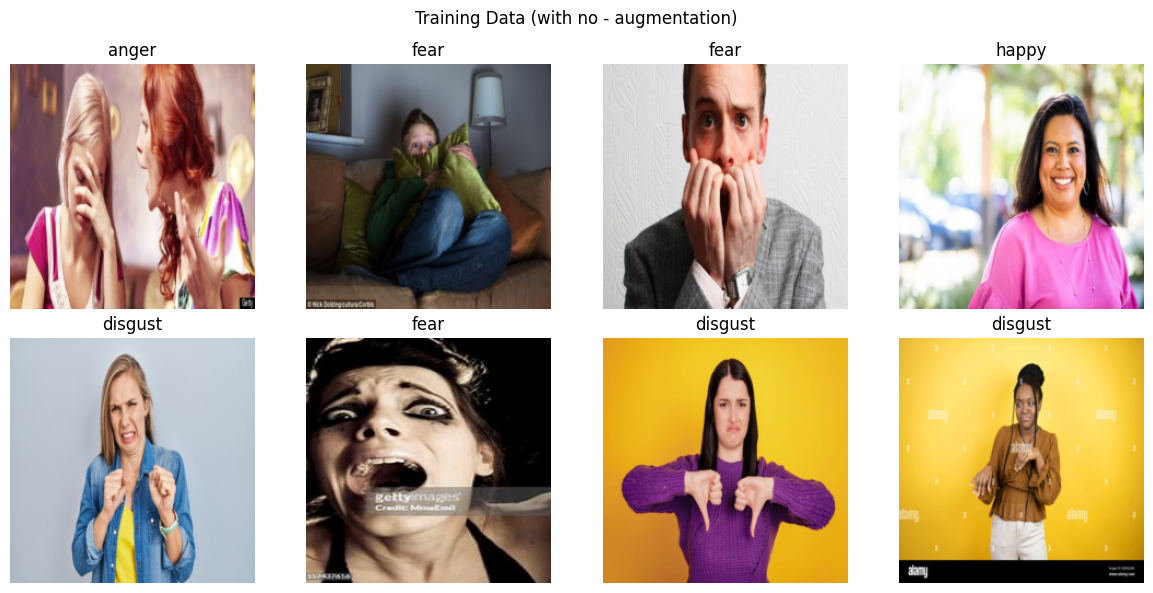

In [5]:
import torch
import torchvision.transforms.v2 as transforms
from torchvision import datasets
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
import copy
# Define image size and normalization parameters
IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

basic_transforms = transforms.Compose([
    transforms.ToImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToDtype(torch.float32, scale=True),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

def get_data_loader(basic_transforms, augmentation_transforms):

    # Update the dataset path for PyTorch DataLoader
    dataset_path = os.path.join(path, FOLDER_NAME)

    # Load dataset with correct path
    full_dataset = datasets.ImageFolder(dataset_path)
    print(f"Total images: {len(full_dataset)}")
    print(f"Classes: {full_dataset.classes}")

    # Stratified split (70/15/15)
    train_size = int(0.7 * len(full_dataset))
    val_size = int(0.15 * len(full_dataset))
    test_size = len(full_dataset) - train_size - val_size

    train_dataset_origin, val_dataset_origin, test_dataset_origin = random_split(
        full_dataset, [train_size, val_size, test_size],
        generator=torch.Generator().manual_seed(42)  # Reproducible splits
    )

    # Apply different transforms to validation and test sets
    print(f'data set path = {dataset_path}')
    val_dataset = copy.deepcopy(train_dataset_origin)
    test_dataset = copy.deepcopy(val_dataset_origin)
    train_dataset = copy.deepcopy(test_dataset_origin)

    val_dataset.dataset.transform = basic_transforms
    test_dataset.dataset.transform = basic_transforms
    train_dataset.dataset.transform = augmentation_transforms
    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)
    print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

    print(id(train_loader.dataset.dataset), id(val_loader.dataset.dataset), id(test_loader.dataset.dataset))
    return train_loader, val_loader, test_loader, full_dataset

# Visualize preprocessing effects
def show_batch(loader, title, full_dataset):
    batch, labels = next(iter(loader))
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))

    for i in range(8):
        img = batch[i]
        # Denormalize for visualization
        img = img * torch.tensor(IMAGENET_STD).view(3, 1, 1) + torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
        img = torch.clamp(img, 0, 1)

        ax = axes[i//4, i%4]
        ax.imshow(img.permute(1, 2, 0))
        ax.set_title(f"{full_dataset.classes[labels[i]]}")
        ax.axis('off')

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# Show examples
train_loader, val_loader, test_loader, full_dataset = get_data_loader(basic_transforms, basic_transforms)
show_batch(train_loader, "Training Data (with no - augmentation)", full_dataset)

- **Note: Create independent dataset instances for each split `val_dataset = copy.deepcopy(train_dataset_origin)`. Otherwise, if splits share the same underlying dataset, setting the training transform will also affect the validation and test sets.**

### B. Build a deep learning model for this classification task

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import time

class EmotionCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64*56*56, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )
        self.train_acc = []
        self.val_acc = []
        self.train_loss = []
        self.val_loss = []

    def forward(self, x):
        return self.net(x)

    def train_epoch(self, dataloader, testloader, device, epochs=20):
        self.to(device)
        ROOT = Path('/content/drive/MyDrive/ass_3')
        best_acc = 0.0
        best_path = str(ROOT / "emotioncnn_best.pt")
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(self.parameters(), lr=0.001)
        start_time = time.time()
        for epoch in range(epochs):
            # Reset per-epoch counters
            self.train()
            epoch_loss = 0
            correct = 0
            total = 0

            for inputs, labels in dataloader:
                inputs, labels = inputs.to(device), labels.to(device)

                optimizer.zero_grad()
                outputs = self(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

                epoch_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

            # Per-epoch metrics
            train_acc = 100.0 * correct / total
            avg_loss = epoch_loss / len(dataloader)

            # Validation
            val_acc, val_loss = self.evaluate(testloader, device, criterion)
            if val_acc > best_acc:
                best_acc = val_acc
                torch.save(self.state_dict(), best_path)
                print(f"Saved best checkpoint (acc={best_acc:.3f})")
            # Store metrics
            self.train_acc.append(train_acc)
            self.train_loss.append(avg_loss)

            if epoch % 10 == 0:
                print(f"Epoch {epoch+1}: Train Acc={train_acc:.1f}%, Val Acc={val_acc:.1f}%")
        end_time = time.time()
        total = end_time - start_time
        print(f"Training time: {total:.2f} seconds")
    def evaluate(self, testloader, device, criterion):
        self.eval()
        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for inputs, labels in testloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = self(inputs)

                # Calculate loss for this batch
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                # Calculate accuracy
                _, predicted = torch.max(outputs, 1)
                correct += (predicted == labels).sum().item()
                total += labels.size(0)

        # Calculate average metrics
        avg_val_loss = val_loss / len(testloader)
        val_acc = 100.0 * correct / total

        # Store validation metrics
        self.val_acc.append(val_acc)
        self.val_loss.append(avg_val_loss)
        return val_acc, avg_val_loss



### **Layer Analysis:**

### **1. First Convolutional Layer (Conv2d: 3→32)**
- **Purpose:** Extracts low-level spatial features like edges, textures, and basic facial contours from RGB input images.
- **Training Effect:** 896 parameters (3×3×3×32+32); low computational cost; learns foundational feature detectors through backpropagation.
- **Emotion Recognition:** Detects fundamental facial elements like eye edges, mouth corners, and eyebrow shapes that form the basis for emotion classification.

### **2. First ReLU Activation**
- **Purpose:** Introduces non-linearity by applying f(x) = max(0,x), enabling the network to learn complex patterns beyond linear combinations.
- **Training Effect:** Zero parameters; computationally efficient; prevents vanishing gradients but risks dead neurons if inputs become consistently negative.
- **Emotion Recognition:** Allows detection of directional facial features (upward vs downward mouth curves) critical for distinguishing happy from sad expressions.

### **3. First MaxPooling (2×2)**
- **Purpose:** Reduces spatial dimensions from 224×224 to 112×112 while retaining the strongest feature responses in each 2×2 region.
- **Training Effect:** Zero parameters; reduces computation by 75%; provides translation invariance but risks losing fine-grained spatial information.
- **Emotion Recognition:** Makes the model robust to slight variations in face position while preserving prominent emotional features like eye width or mouth shape.

### **4. First Dropout (0.25)**
- **Purpose:** Randomly sets 25% of neurons to zero during training to prevent over-reliance on specific feature combinations.
- **Training Effect:** Zero parameters; strong regularization technique; reduces overfitting risk but may slow initial convergence.
- **Emotion Recognition:** Prevents memorizing specific facial identities in the small dataset (~1200 images), forcing the model to learn generalizable emotion patterns.

### **5. Second Convolutional Layer (Conv2d: 32→64)**
- **Purpose:** Combines low-level features into more complex patterns, detecting facial components like eye shapes, mouth regions, and facial symmetries.
- **Training Effect:** 18,496 parameters (3×3×32×64+64); moderate computational cost; learns hierarchical feature representations.
- **Emotion Recognition:** Detects mid-level emotion indicators like frowning patterns (anger), wide-open eyes (fear), or raised cheeks (happiness).

### **6. Second ReLU Activation**
- **Purpose:** Applies non-linearity to the second convolutional layer's outputs, enabling detection of complex facial feature interactions.
- **Training Effect:** Zero parameters; maintains gradient flow through deeper layers; essential for learning non-linear emotion mappings.
- **Emotion Recognition:** Enables recognition of subtle emotion combinations, such as distinguishing pain (tightened features) from disgust (wrinkled nose).

### **7. Second MaxPooling (2×2)**
- **Purpose:** Further reduces spatial dimensions from 112×112 to 56×56, creating more abstract feature representations.
- **Training Effect:** Zero parameters; additional 75% computation reduction; increases receptive field but may lose fine emotional details.
- **Emotion Recognition:** Focuses on overall facial expression patterns rather than pixel-level details, improving robustness to lighting and pose variations.

### **8. Flatten Layer**
- **Purpose:** Reshapes 3D feature maps (64×56×56) into a 1D vector (200,704 elements) for compatibility with fully connected layers.
- **Training Effect:** Zero parameters; necessary architectural transition; creates high-dimensional feature vector from spatial representations.
- **Emotion Recognition:** Converts spatial facial features into a global representation where emotion classification can be performed through learned combinations.

### **9. First Fully Connected Layer (Linear: 200,704→128)**
- **Purpose:** Maps the high-dimensional flattened features to a compressed 128-dimensional representation, learning global emotion patterns.
- **Training Effect:** 25,690,240 parameters; major computational bottleneck; extremely prone to overfitting without careful regularization.
- **Emotion Recognition:** Combines all facial features into abstract emotion representations, learning which feature combinations correspond to specific emotions.

### **10. Third ReLU Activation**
- **Purpose:** Applies final non-linearity before classification, enabling complex decision boundaries between emotion classes.
- **Training Effect:** Zero parameters; enables non-linear emotion classification; critical for separating similar emotions like fear and surprise.
- **Emotion Recognition:** Allows the model to create complex emotion decision rules that may involve multiple facial regions simultaneously.

### **11. Second Dropout (0.5)**
- **Purpose:** Applies aggressive 50% dropout to the dense layer, providing strong regularization against overfitting in the parameter-heavy section.
- **Training Effect:** Zero parameters; crucial regularization for the massive fully connected layer; prevents memorization of training examples.
- **Emotion Recognition:** Essential for generalization in emotion recognition, preventing the model from memorizing specific face-emotion pairs rather than learning transferable patterns.

### **12. Output Layer (Linear: 128→6)**
- **Purpose:** Maps the 128-dimensional emotion representation to 6 raw classification scores (logits) for each emotion class.
- **Training Effect:** 774 parameters (128×6+6); minimal computational cost; final decision-making layer trained via cross-entropy loss.
- **Emotion Recognition:** Produces final emotion predictions by learning optimal linear combinations of the abstract features for distinguishing between Happy, Sad, Fear, Pain, Anger, and Disgust.

**Note:** Your model does **not** include Batch Normalization layers, so that section should be removed from your description.

Based on your **actual model architecture**, here are the layer descriptions:



### C: Three independent checks to detect overfitting

In [ ]:
# Model with augmentation
model = EmotionCNN(num_classes = 6)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.train_epoch(train_loader, val_loader, device, epochs=15)

Epoch 1: Train Acc=18.5%, Val Acc=20.1%
Epoch 11: Train Acc=65.8%, Val Acc=38.0%
Training time: 164.78 seconds


1. Plot Training and validation to check overfitting

In [13]:
def show_splot_compare_train_val(model):
  # Plot both training and validation curves
  plt.figure(figsize=(15, 5))

  plt.subplot(1, 2, 1)
  plt.plot(model.train_acc, 'b-', label='Training Accuracy')
  plt.plot(model.val_acc, 'r-', label='Validation Accuracy')
  plt.title('Accuracy vs Epochs')
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy (%)')
  plt.legend()

  plt.subplot(1, 2, 2)
  plt.plot(model.train_loss, 'b-', label='Training Loss')
  plt.plot(model.val_loss, 'r-', label='Validation Loss')
  plt.title('Loss vs Epochs')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.legend()

  plt.tight_layout()
  plt.show()



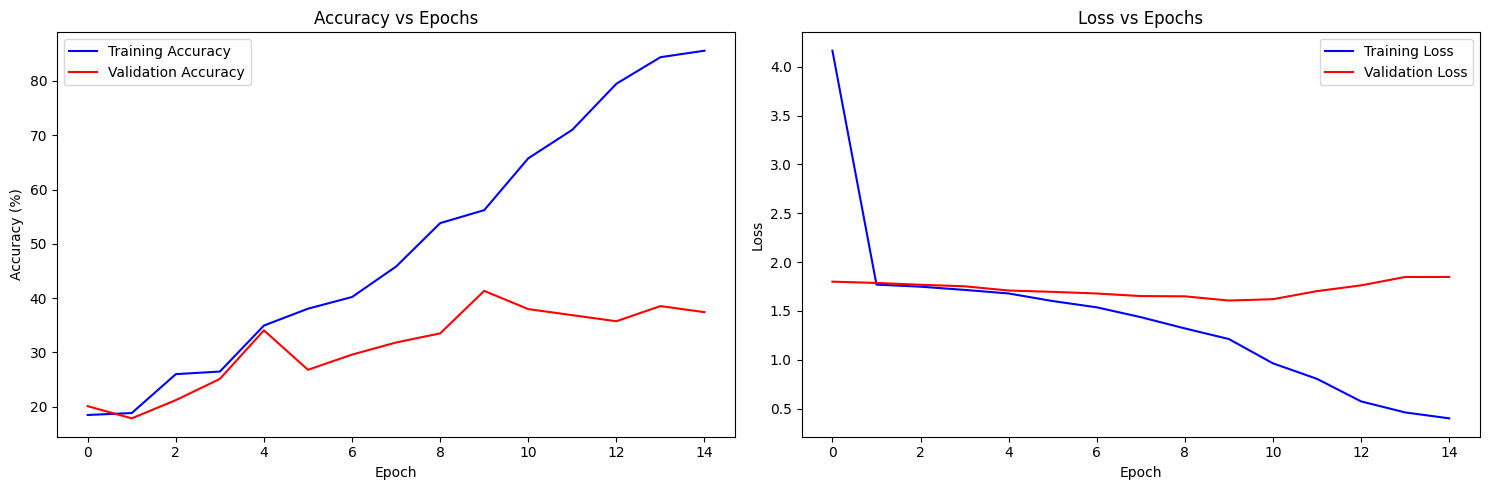

In [ ]:
show_splot_compare_train_val(model)

2. Cross-validate check

In [ ]:
from sklearn.model_selection import KFold
import torch.utils.data as data

def k_fold_validation(full_dataset, k=5, epochs=20):
    """Perform k-fold cross-validation to detect overfitting"""
    kfold = KFold(n_splits=k, shuffle=True, random_state=42)

    fold_results = {
        'train_acc': [],
        'val_acc': [],
        'train_loss': [],
        'val_loss': []
    }

    for fold, (train_ids, val_ids) in enumerate(kfold.split(full_dataset)):
        print(f"\nFold {fold + 1}/{k}")

        # Create data subsets
        train_subset = data.Subset(full_dataset, train_ids)
        val_subset = data.Subset(full_dataset, val_ids)

        # Create data loaders
        train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
        val_loader = DataLoader(val_subset, batch_size=32, shuffle=False)

        # Train model
        model_fold = EmotionCNN(num_classes=6)
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        model_fold.train_epoch(train_loader, val_loader, device, epochs=epochs)

        # Store results
        fold_results['train_acc'].append(model_fold.train_acc[-1])
        fold_results['val_acc'].append(model_fold.val_acc[-1])
        fold_results['train_loss'].append(model_fold.train_loss[-1])
        fold_results['val_loss'].append(model_fold.val_loss[-1])

    return fold_results

# Run k-fold validation
cv_results = k_fold_validation(full_dataset, k=5, epochs=15)

In [ ]:
 # Analyze results
train_mean = np.mean(cv_results['train_acc'])
val_mean = np.mean(cv_results['val_acc'])
train_std = np.std(cv_results['train_acc'])
val_std = np.std(cv_results['val_acc'])

print(f"\nK-Fold Results:")
print(f"Training Accuracy: {train_mean:.2f}% ± {train_std:.2f}%")
print(f"Validation Accuracy: {val_mean:.2f}% ± {val_std:.2f}%")
print(f"Mean Gap: {train_mean - val_mean:.2f}%")

if train_std > 5 or val_std > 5:
    print("HIGH VARIANCE: Model unstable across folds")
if train_mean - val_mean > 10:
    print("OVERFITTING: Consistent train-val gap across folds")


K-Fold Results:
Training Accuracy: 70.70% ± 16.18%
Validation Accuracy: 36.23% ± 3.93%
Mean Gap: 34.47%
HIGH VARIANCE: Model unstable across folds
OVERFITTING: Consistent train-val gap across folds


3. Early stop method

In [ ]:
def train_with_early_stopping(model, train_loader, val_loader, device,
                               max_epochs=100, patience=10, min_delta=0.001):
    """Train with early stopping to detect overfitting point"""
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    best_val_loss = float('inf')
    best_val_acc = 0
    patience_counter = 0
    best_epoch = 0

    train_acc_history = []
    val_acc_history = []
    train_loss_history = []
    val_loss_history = []

    for epoch in range(max_epochs):
        # Training phase
        model.train()
        train_loss = 0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        # Calculate training metrics
        avg_train_loss = train_loss / len(train_loader)
        train_acc = 100.0 * correct / total

        # Validation phase
        val_acc, val_loss = model.evaluate(val_loader, device, criterion)

        # Store history
        train_acc_history.append(train_acc)
        val_acc_history.append(val_acc)
        train_loss_history.append(avg_train_loss)
        val_loss_history.append(val_loss)

        # Early stopping check
        if val_loss < best_val_loss - min_delta:
            best_val_loss = val_loss
            best_val_acc = val_acc
            best_epoch = epoch
            patience_counter = 0
            # Save best model
            torch.save(model.state_dict(), 'best_model.pth')
        else:
            patience_counter += 1

        if epoch % 10 == 0:
            print(f"Epoch {epoch+1}: Train Acc={train_acc:.1f}%, Val Acc={val_acc:.1f}%")

        # Early stopping
        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            print(f"Best validation accuracy: {best_val_acc:.2f}% at epoch {best_epoch+1}")
            break

    # Analyze overfitting
    if best_epoch < len(train_acc_history) - patience:
        print(f"OVERFITTING DETECTED:")
        print(f"- Best validation performance at epoch {best_epoch+1}")
        print(f"- Training continued for {patience} more epochs without improvement")
        print(f"- Final train accuracy: {train_acc_history[-1]:.2f}%")
        print(f"- Best validation accuracy: {best_val_acc:.2f}%")

    return {
        'train_acc': train_acc_history,
        'val_acc': val_acc_history,
        'train_loss': train_loss_history,
        'val_loss': val_loss_history,
        'best_epoch': best_epoch,
        'stopped_early': best_epoch < len(train_acc_history) - patience
    }

# Train with early stopping
model_es = EmotionCNN(num_classes=6)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
results = train_with_early_stopping(model_es, train_loader, val_loader, device,
                                   max_epochs=100, patience=5)

Epoch 1: Train Acc=17.5%, Val Acc=11.2%
Epoch 11: Train Acc=29.2%, Val Acc=29.1%
Epoch 21: Train Acc=87.0%, Val Acc=35.8%

Early stopping at epoch 21
Best validation accuracy: 36.87% at epoch 16
OVERFITTING DETECTED:
- Best validation performance at epoch 16
- Training continued for 5 more epochs without improvement
- Final train accuracy: 86.99%
- Best validation accuracy: 36.87%


**Discuss mitigations**:
To address the identified overfitting issues, several mitigation strategies can be implemented. First, data augmentation techniques such as random horizontal flips, rotations, and color jitter should be applied to the training set to artificially increase dataset diversity and prevent the model from memorizing specific image features. Second, regularization techniques including increasing dropout rates from 0.25/0.5 to 0.3/0.6 and adding L2 weight decay will help reduce model complexity and prevent overfitting to training data. Third, architectural modifications such as adding batch normalization layers after convolutions and reducing the massive fully connected layer size

**D. Evaluation Metrics for Multi-Class Emotion Classification**

F1-Score: F1-Score calculates the unweighted mean of F1-scores across all six emotion classes, treating minority classes equally with majority classes. This prevents the model from appearing successful by only predicting frequent emotions while ignoring rare but critical ones like Fear or Pain.

Recall: measures the model's ability to correctly identify each emotion when it actually occurs, which is crucial for applications like mental health monitoring where missing Fear or Pain could prevent necessary interventions. Low recall for specific emotions reveals which classes need targeted improvement.

Confusion Matrix: reveals systematic misclassification patterns between similar emotions (e.g., Fear vs Pain, Anger vs Disgust), providing actionable insights for model improvement. Unlike aggregate metrics, it shows exactly which emotion pairs are problematic and need additional discriminative features.

**Why Accuracy is Insufficient:** Accuracy can be misleadingly high in imbalanced datasets, a model could achieve 70% accuracy by simply predicting the three most common classes while completely failing on Fear and Pain, making it useless for real-world emotion detection.

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Overall Accuracy: 0.4254 (42.54%)

Macro-averaged Metrics:
Macro F1-Score: 0.4265
Macro Precision: 0.4270
Macro Recall: 0.4391

Per-Class Performance:
Class      Precision  Recall     F1-Score   Support   
-------------------------------------------------------
Anger      0.4348     0.2632     0.3279     38        
Disgust    0.5278     0.6129     0.5672     31        
Fear       0.3226     0.4762     0.3846     21        
Happy      0.3750     0.3659     0.3704     41        
Pain       0.4500     0.4500     0.4500     20        
Sad        0.4516     0.4667     0.4590     30        


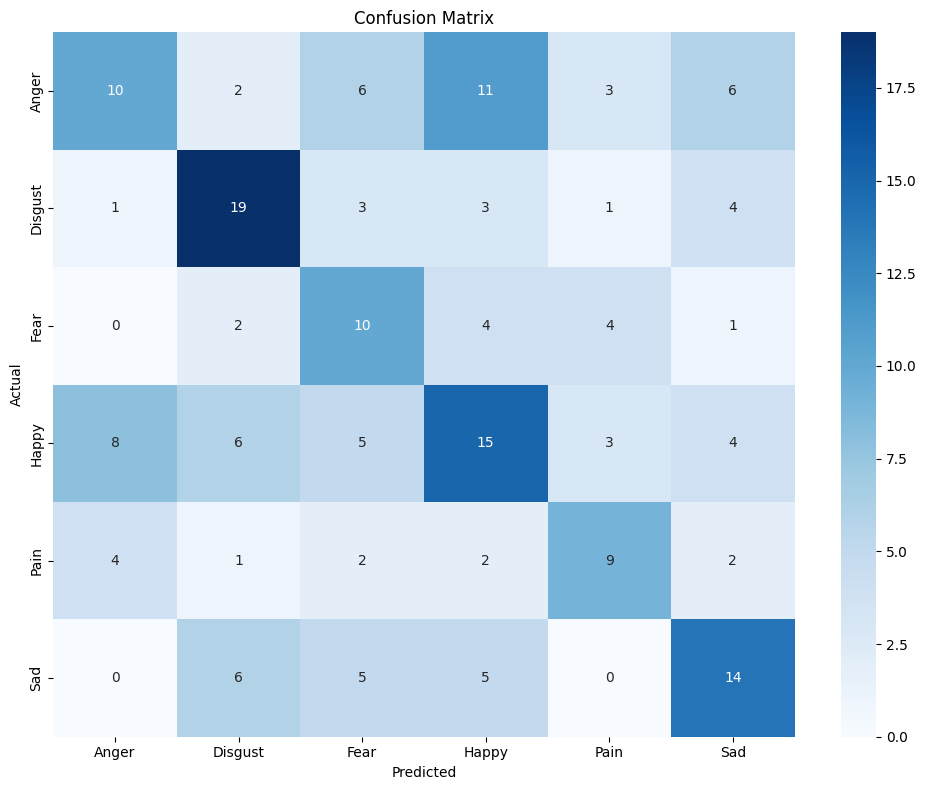


Most Confused Emotion Pairs:
Anger → Fear: 6 misclassifications
Anger → Happy: 11 misclassifications
Anger → Sad: 6 misclassifications
Happy → Anger: 8 misclassifications
Happy → Disgust: 6 misclassifications
Sad → Disgust: 6 misclassifications

Class Imbalance Impact Analysis:
Best performing class: Disgust (F1: 0.5672)
Worst performing class: Anger (F1: 0.3279)
Minority classes average F1: 0.4173
Majority classes average F1: 0.3491
Model handles class imbalance reasonably well


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_recall_fscore_support
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import numpy as np

def evaluate_model_performance(model, test_loader, device, class_names):
    """Calculate comprehensive performance metrics"""
    model.eval()
    all_predictions = []
    all_labels = []

    # Get predictions
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Convert to numpy arrays
    y_true = np.array(all_labels)
    y_pred = np.array(all_predictions)

    return y_true, y_pred

def calculate_all_metrics(y_true, y_pred, class_names):
    """Calculate and display all required metrics"""

    # 1. Overall Accuracy
    accuracy = (y_true == y_pred).sum() / len(y_true)
    print(f"Overall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

    # 2. Per-class Precision, Recall, F1-score
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, average=None, labels=range(len(class_names))
    )

    # 3. Macro-averaged metrics
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    macro_precision = precision_recall_fscore_support(y_true, y_pred, average='macro')[0]
    macro_recall = precision_recall_fscore_support(y_true, y_pred, average='macro')[1]

    print(f"\nMacro-averaged Metrics:")
    print(f"Macro F1-Score: {macro_f1:.4f}")
    print(f"Macro Precision: {macro_precision:.4f}")
    print(f"Macro Recall: {macro_recall:.4f}")

    # 4. Per-class detailed report
    print(f"\nPer-Class Performance:")
    print(f"{'Class':<10} {'Precision':<10} {'Recall':<10} {'F1-Score':<10} {'Support':<10}")
    print("-" * 55)
    for i, class_name in enumerate(class_names):
        print(f"{class_name:<10} {precision[i]:<10.4f} {recall[i]:<10.4f} {f1[i]:<10.4f} {support[i]:<10}")

    return {
        'accuracy': accuracy,
        'macro_f1': macro_f1,
        'macro_precision': macro_precision,
        'macro_recall': macro_recall,
        'per_class_precision': precision,
        'per_class_recall': recall,
        'per_class_f1': f1,
        'support': support
    }

def plot_confusion_matrix(y_true, y_pred, class_names):
    """Plot and analyze confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    # Analyze most confused pairs
    print("\nMost Confused Emotion Pairs:")
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            if i != j and cm[i,j] > 5:  # Significant misclassifications
                print(f"{class_names[i]} → {class_names[j]}: {cm[i,j]} misclassifications")

    return cm

def analyze_class_imbalance_impact(metrics, class_names):
    """Analyze how class imbalance affects performance"""
    print(f"\nClass Imbalance Impact Analysis:")

    # Find best and worst performing classes
    f1_scores = metrics['per_class_f1']
    best_class = np.argmax(f1_scores)
    worst_class = np.argmin(f1_scores)

    print(f"Best performing class: {class_names[best_class]} (F1: {f1_scores[best_class]:.4f})")
    print(f"Worst performing class: {class_names[worst_class]} (F1: {f1_scores[worst_class]:.4f})")

    # Check if minority classes perform worse
    support = metrics['support']
    minority_classes = np.argsort(support)[:2]  # Two smallest classes
    majority_classes = np.argsort(support)[-2:]  # Two largest classes

    minority_avg_f1 = np.mean([f1_scores[i] for i in minority_classes])
    majority_avg_f1 = np.mean([f1_scores[i] for i in majority_classes])

    print(f"Minority classes average F1: {minority_avg_f1:.4f}")
    print(f"Majority classes average F1: {majority_avg_f1:.4f}")

    if minority_avg_f1 < majority_avg_f1 - 0.1:
        print("Significant class imbalance impact detected!")
    else:
        print("Model handles class imbalance reasonably well")

# Execute complete evaluation
class_names = ['Anger', 'Disgust', 'Fear', 'Happy', 'Pain', 'Sad']
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Get predictions
y_true, y_pred = evaluate_model_performance(model, test_loader, device, class_names)

# Calculate all metrics
metrics = calculate_all_metrics(y_true, y_pred, class_names)

# Plot confusion matrix
cm = plot_confusion_matrix(y_true, y_pred, class_names)

# Analyze class imbalance impact
analyze_class_imbalance_impact(metrics, class_names)

Briefly Discussion of Model Performance:
- For this multi-class emotion classification task with class imbalance, the Confusion Matrix, Per-Class F1-Scores, and Macro-Averaged F1-Score are the most appropriate and informative metrics. They provide a comprehensive view of performance, highlighting strengths and weaknesses across different emotions and revealing specific areas for improvement. While precision and recall are also important, the F1-score provides a single balanced metric for each class. Accuracy is not a reliable metric in this scenario due to the class imbalance

## **Task 2 (C Task) Analyse and improve the model**

### Task 2.1 Build an input pipeline for data augmentation

 A. Propose and implement a preprocessing pipeline that uses at least three augmentation techniques of your choice.

In [6]:
import torchvision.transforms.v2 as transforms
# Enhanced augmentation pipeline with Random Crop
augmentation_transforms = transforms.Compose([
    transforms.ToImage(),
    transforms.Resize((256, 256)),  # Resize larger first for cropping

    # Augmentation Technique 1: Random Crop
    transforms.RandomResizedCrop(
        size=(224, 224),           # Final output size
        scale=(0.8, 1.0),         # Crop 80-100% of original image
        ratio=(0.9, 1.1),         # Aspect ratio range (slightly rectangular)
        interpolation=transforms.InterpolationMode.BILINEAR
    ),

    # Augmentation Technique 2: Random Horizontal Flip
    transforms.RandomHorizontalFlip(p=0.5),

    # Augmentation Technique 3: Random Rotation (emotion-safe)
    transforms.RandomRotation(degrees=(-8, 8)),

    # Augmentation Technique 4: Color Jitter
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.15,
        saturation=0.1,
        hue=0.03
    ),

    transforms.ToDtype(torch.float32, scale=True),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

B. Justification for the chosen augmentation techniques:

- RandomHorizontalFlip: Introduces invariance to horizontal pose/orientation. Facial expressions are often symmetrical, so flipping helps the model recognize emotions regardless of which side of the face is more prominent or the direction the person is facing horizontally.
- RandomRotation (degrees=10): Introduces invariance to small rotations of the face/head. People don't always pose perfectly centered or upright. Small rotations help the model generalize to slight variations in head tilt.
- RandomCrop (size=28, padding=2): Introduces invariance to minor shifts and variations in the positioning of the face within the image, and helps the model focus on features rather than the exact location. It simulates slight variations in framing or zoom. Note: A crop size of 28 pixels is very small given the input size of 224x224; this may need adjustment depending on the desired effect.

C. How does augmentation contribute to improving generalization in deep learning models?
- Data augmentation improves generalization by artificially increasing the diversity of the training data. This prevents the model from memorizing specific examples and forces it to learn more robust, invariant features that are present in various transformations of the original images. This increased exposure to variations helps the model perform better on unseen data.

D. In what ways can augmentation help mitigate class imbalance?

- Augmentation can help mitigate class imbalance by artificially creating more diverse examples for the minority classes. By applying transformations (like flips, rotations, crops, color jitter) specifically to images in underrepresented categories, we increase the effective sample size and variability of those classes during training. This gives the model more opportunities to learn the features associated with minority emotions, reducing the bias towards majority classes that arises from imbalanced data distribution.

E. Discuss how augmentationn might alter training dynamic

- Augmentation can potentiolly slow down convergence speed as the model sees mor varied examples each epoch, requiring more updates to find a stable minimum. It also increases training time per epoch due to computational cost of applying trasformations to each image during loading. However, this trade-off is often necessary for better generalization

F. Compare the performance of your model with and without augmentation. What changes do you observe in accuracy, F1-scores, and per-class performance?

In [ ]:
# Model with no-augmentation
train_loader, val_loader, test_loader, full_dataset = get_data_loader(basic_transforms = basic_transforms, transforms = basic_transforms)
model_augmentation = EmotionCNN(num_classes = 6)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_augmentation.train_epoch(train_loader, val_loader, device, epochs=20)

Total images: 1198
Classes: ['anger', 'disgust', 'fear', 'happy', 'pain', 'sad']
data set path = /kaggle/input/sentiment-images-classifier/6 Emotions for image classification
Train: 838, Val: 179, Test: 181
Epoch 1: Train Acc=18.6%, Val Acc=15.6%
Epoch 11: Train Acc=28.4%, Val Acc=23.5%


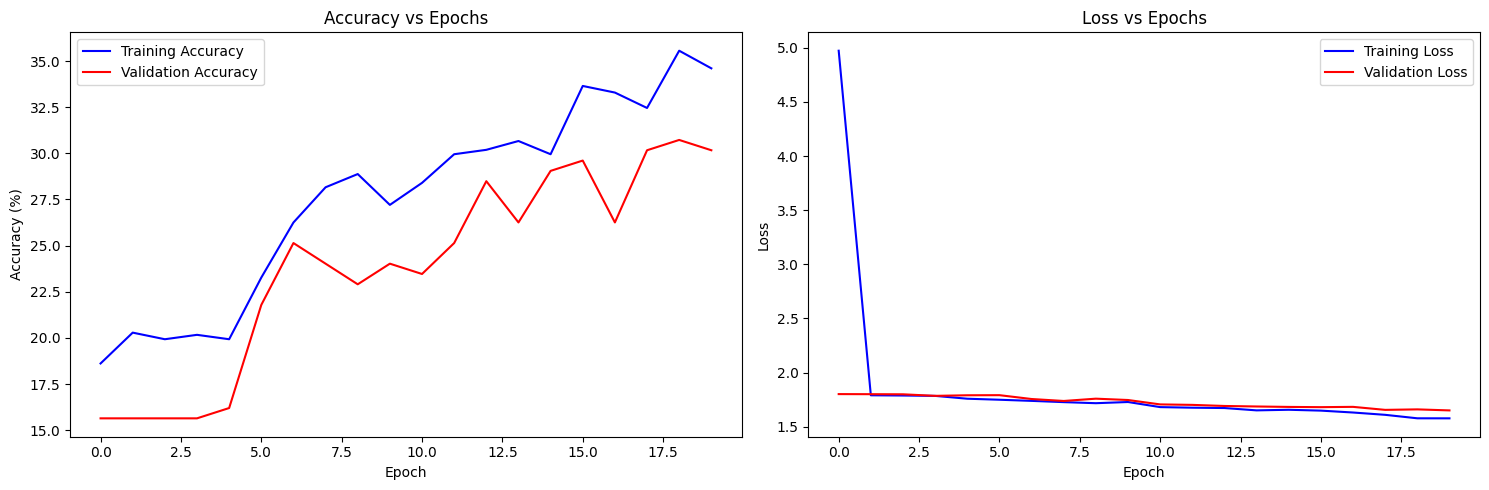

In [ ]:
show_splot_compare_train_val(model_augmentation)

In [ ]:
# Model with augmentation
train_loader, val_loader, test_loader, full_dataset = get_data_loader(basic_transforms = basic_transforms, transforms = augmentation_transforms)
model_augmentation = EmotionCNN(num_classes = 6)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_augmentation.train_epoch(train_loader, val_loader, device, epochs=100)

Total images: 1198
Classes: ['anger', 'disgust', 'fear', 'happy', 'pain', 'sad']
data set path = /kaggle/input/sentiment-images-classifier/6 Emotions for image classification
Train: 838, Val: 179, Test: 181
Epoch 1: Train Acc=17.9%, Val Acc=11.2%
Epoch 11: Train Acc=27.7%, Val Acc=32.4%
Epoch 21: Train Acc=37.1%, Val Acc=35.2%
Epoch 31: Train Acc=38.4%, Val Acc=33.5%
Epoch 41: Train Acc=39.9%, Val Acc=39.1%
Epoch 51: Train Acc=42.8%, Val Acc=36.9%
Epoch 61: Train Acc=46.7%, Val Acc=41.3%
Epoch 71: Train Acc=48.4%, Val Acc=40.2%
Epoch 81: Train Acc=53.1%, Val Acc=41.3%
Epoch 91: Train Acc=51.8%, Val Acc=38.5%


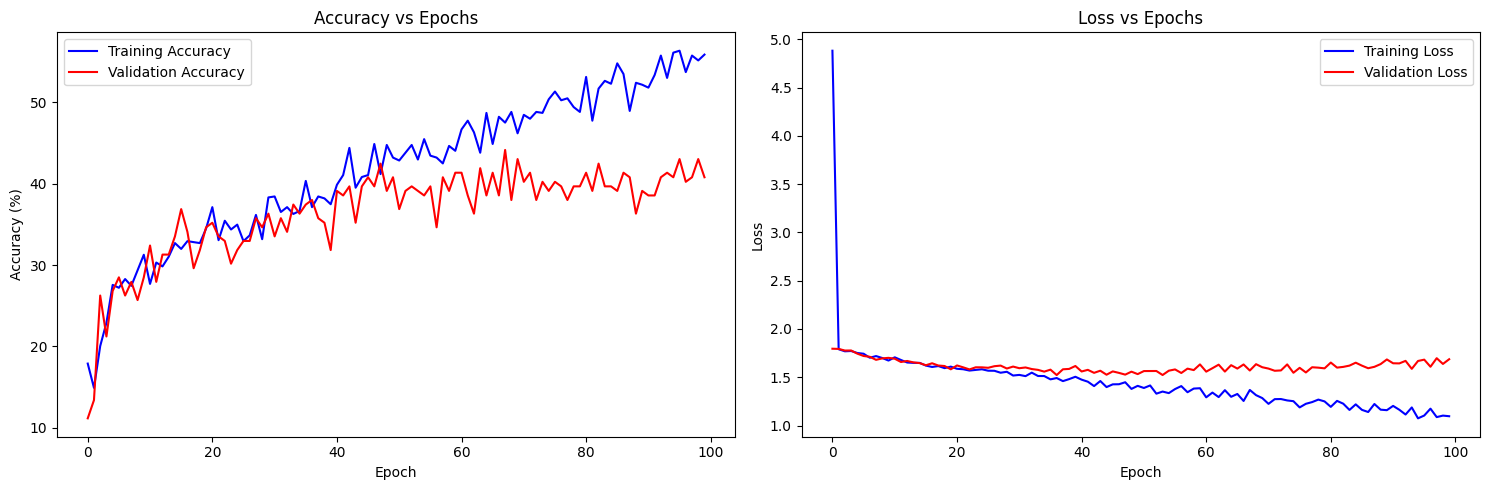

In [ ]:
show_splot_compare_train_val(model_augmentation)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Overall Accuracy: 0.4144 (41.44%)

Macro-averaged Metrics:
Macro F1-Score: 0.4054
Macro Precision: 0.4258
Macro Recall: 0.3978

Per-Class Performance:
Class      Precision  Recall     F1-Score   Support   
-------------------------------------------------------
Anger      0.5769     0.3947     0.4688     38        
Disgust    0.5926     0.5161     0.5517     31        
Fear       0.2500     0.2381     0.2439     21        
Happy      0.3448     0.4878     0.4040     41        
Pain       0.4375     0.3500     0.3889     20        
Sad        0.3529     0.4000     0.3750     30        


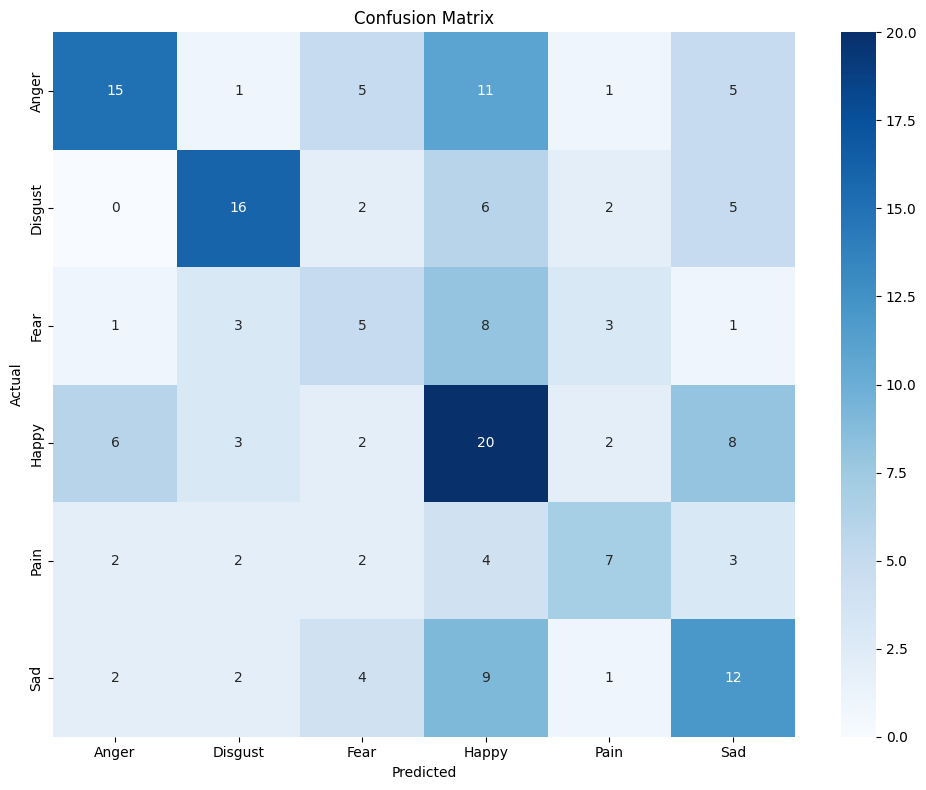


Most Confused Emotion Pairs:
Anger → Happy: 11 misclassifications
Disgust → Happy: 6 misclassifications
Fear → Happy: 8 misclassifications
Happy → Anger: 6 misclassifications
Happy → Sad: 8 misclassifications
Sad → Happy: 9 misclassifications

Class Imbalance Impact Analysis:
Best performing class: Disgust (F1: 0.5517)
Worst performing class: Fear (F1: 0.2439)
Minority classes average F1: 0.3164
Majority classes average F1: 0.4364
Significant class imbalance impact detected!


In [ ]:
# Execute complete evaluation
class_names = ['Anger', 'Disgust', 'Fear', 'Happy', 'Pain', 'Sad']
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Get predictions
y_true, y_pred = evaluate_model_performance(model_augmentation, test_loader, device, class_names)

# Calculate all metrics
metrics = calculate_all_metrics(y_true, y_pred, class_names)

# Plot confusion matrix
cm = plot_confusion_matrix(y_true, y_pred, class_names)

# Analyze class imbalance impact
analyze_class_imbalance_impact(metrics, class_names)

**Compare the performace**

Based on the performance results (accuracy, F1-score), we observe that the validation accuracy line starts to catch up with the training accuracy line from epoch 1 to 50. This indicates that augmentation is helping to reduce overfitting (ultimately, it still can not mitigate the overfitting). While the overall accuracy hasn't significantly improved, this is likely due to the small dataset size. We will focus on improving accuracy further in Task 3 by using Transfer Learning

H. Reflect on the computational trade-offs: if augmentation effectively doubles or triples your dataset, how might this influence scalability and training cost?

Augmentation increases training time per epoch and may require more epochs to converge, increasing overall training cost. It also demands more from the data loading pipeline. However, it improves generalization without significantly increasing storage.

## Task 2.2 Compare the performance under equal training time

A. If you constrain both the baseline and augmented models to the same training budget (e.g., fixed number of epochs, gradient updates, or wall-clock time), does augmentation still improve performance?

- Run the model with augmented data for 20 epochs (the same number of epochs as the non-augmented model) to compare performance.

In [18]:
# Model with augmentation
train_loader, val_loader, test_loader, full_dataset = get_data_loader(basic_transforms, augmentation_transforms)
model_augmentation = EmotionCNN(num_classes = 6)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_augmentation.train_epoch(train_loader, val_loader, device, epochs=20)

Total images: 1198
Classes: ['anger', 'disgust', 'fear', 'happy', 'pain', 'sad']
data set path = /kaggle/input/sentiment-images-classifier/6 Emotions for image classification
Train: 181, Val: 838, Test: 179
132028457878256 132028449179360 132028449179456
Epoch 1: Train Acc=18.8%, Val Acc=18.3%
Epoch 11: Train Acc=19.9%, Val Acc=16.3%
Training time: 491.99 seconds


- Analyze: As we can see, the validation accuracy performance starts to improve from epoch 9 when using augmented data. The training time without augmentation is 262.50 seconds, whereas the training time with augmented data is approximately double at 491.99 seconds.

B. Efficiency and Cost-Effectiveness of Augmentation: Augmentation increases training time per epoch significantly (nearly doubling it in this case). While it can improve validation performance, it is less computationally efficient and more costly in terms of training time compared to training without augmentation for the same number of epochs.

C. Justification of Additional Computational Expense: Yes, the improvements in robustness and generalization generally justify the additional computational expense, especially for limited datasets. Augmentation helps the model learn more robust features, reducing overfitting and improving performance on unseen data, which is critical for real-world application and overall model reliability, even if it takes longer to train.

## Task 2.3 Identifying model strengths and weaknesses

A. Examine misclassified samples from your model. What patterns do you notice across these errors
*   **Happy is frequently confused with other emotions:** "Happy" is a common misclassification target from "Anger", "Disgust", "Fear", and "Sad". It is also misclassified as "Anger" and "Sad". **Even though the happy data has the largest dataset (230 sample)**.This suggests that the model struggles to distinguish "Happy" from other emotions, possibly due to subtle differences in facial expressions or the dataset's representation of happiness.
*   **Confusion between similar emotions:** There are misclassifications between emotions that can have similar facial cues, such as "Anger" and "Happy", and "Happy" and "Sad". This highlights the difficulty in distinguishing between emotions that might share some visual characteristics.
*   **Fear is poorly classified:** "Fear" has the lowest F1-score (0.2439) and is frequently misclassified as "Happy". This indicates a significant weakness in the model's ability to correctly identify fear, which could be due to limited or ambiguous examples of fear in the training data (smallest dataset 163 samples).

B. How might augmentation or other preprocessing methods be refined to specifically target these weaknesses?

To specifically target the identified weaknesses (confusion between emotions and poor performance on minority classes), augmentation and other preprocessing methods can be refined as follows:

*   **Targeted Augmentation for Minority Classes:** Apply more aggressive or diverse augmentation techniques (e.g., wider rotation angles, more significant color jitter, elastic transformations) specifically to the images of minority classes (Fear, Pain) to increase their representation and variability in the training data.
*   **Emotion-Specific Augmentation:** Carefully consider augmentation techniques that preserve or even emphasize key emotional features. For example, avoid extreme transformations that might distort facial expressions crucial for distinguishing between similar emotions.
*   **Preprocessing for Feature Emphasis:** Techniques that enhance specific facial features (e.g., edge detection, landmark detection) could be explored and integrated into the preprocessing pipeline to provide the model with more explicit cues for emotion recognition, especially for differentiating between similar expressions.
*   **Preprocessing Enhancements to Reduce Overfitting:** Implement mixup or cutmix during training to blend images from different classes, creating smoother decision boundaries

C. Could certain augmentations unintentionally harm performance (e.g., rotations making “happy” resemble “surprised”)? How would you balance the benefits and risks?

Augmentations can hurt when they stop being label‑preserving.
Examples:
- Large rotations/vertical flips distort mouth/eyebrow cues, heavy crops remove key regions.
- Strong color jitter/blur alters skin tone or contrast used by the model.
- Elastic/cutout/CutMix can hide discriminative areas; mixup with similar classes adds label noise.

Balance benefits vs risks:
- Constrain severity: rotation ±8–10°, crop scale ≥0.8, mild jitter (bright ≤0.2, contrast ≤0.15, sat ≤0.1, hue ≤0.03), no vertical flips.
- Use class-conditional policies: gentler aug for classes often confused (e.g., Happy vs Surprise), stronger only for robust cues, oversample minorities with mild aug.
- Face-aware aug: detect face/landmarks and avoid occluding eyes/mouth, keep key regions in crop.
- Validate with ablations: sweep prob/magnitude, pick settings that improve macro‑F1 and per‑class recall without increasing specific confusions.
- Prefer safer methods: mixup (alpha 0.2–0.4), AugMix/RandAugment with tuned magnitude, add test‑time augmentation for robustness without label noise.

D. Based on your analysis, propose at least one concrete refinement to your augmentation strategy and explain why it may be effective.

**Concrete Augmentation Refinement**

**Targeted Augmentation for Minority Classes (Fear and Pain):** Apply a higher probability (e.g., p=0.8 instead of p=0.5) and potentially a wider range of parameters for augmentation techniques like Random Rotation and Color Jitter specifically to images belonging to the "Fear" and "Pain" classes during training.

**Why it may be effective:** The analysis showed that "Fear" and "Pain" are minority classes with lower F1-scores and are prone to misclassification. By applying more aggressive and frequent augmentation to these classes, we effectively increase the number and diversity of training examples for these underrepresented emotions. This helps the model learn more robust and discriminative features for "Fear" and "Pain", reducing the bias towards majority classes and improving the model's ability to correctly identify these crucial emotions.

## **Task 3 (D Task) Improve model generalisability across domains**